# Week 10 - Introduction to Neural Networks: Part II

**Darren Lim**

### Aims

The main concepts covered in this notebook are: 

>* getting familiar with stochastic gradient descent and the role of the learning rate and batch size
>* ways to cope with overfitting, including early stopping, regularization, and dropout
>* incorporating the keras model into an sklearn pipeline

It may be helpful to have last week's notebook open to recall how to build, compile, and fit neural networks in keras.

When completing worksheets:

>- You will have tasks tagged by (CORE) and (EXTRA). 
>- Your primary aim is to complete the (CORE) components during the WS session, afterwards you can try to complete the (EXTRA) tasks for your self-learning process. 

Instructions for submitting your workshops can be found at the end of worksheet. As a reminder, you must submit a pdf of your notebook on Learn by 16:00 PM on the Friday of the week the workshop was given.

# Setup <a id='setup'></a>

First, we need to install the versions of tensorflow and keras needed for this workshop. The versions in Notable's Machine Learning and Language notebook are older, so anyone using Noteable, should start a Python 3 notebook and then uncomment the lines below to install the correct versions.

In [1]:
#!pip install tensorflow==2.20.0
#!pip install tf-keras==2.20.1


## Packages

Let's load the some of the packages needed for this workshop. 

In [2]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

2026-03-25 16:03:14.580534: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-25 16:03:14.580945: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-25 16:03:14.632453: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-25 16:03:15.744093: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

# Part 1: Motorcycle Data

In the first part of this workshop, we will work with the motorcyle data, which giving a series of measurements of head acceleration in a simulated motorcycle accident, used to test crash helmets.

This is a small data set with only 1 feature (time) and 1 numerical outcome (head acceleration) recorded at $N=133$ time points, but we will use it illustrate the role of some of parameters in neural networks and gradient descent.


In [3]:
# Load motorcycle data
mcycle = pd.read_csv('mcycle.csv', index_col=0)
N = mcycle.shape[0]
D = mcycle.shape[1]-1
y = mcycle['accel']
X = mcycle.drop('accel', axis=1)
print('Number of observations: ', N)

# Scale the inputs
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X = ss.fit_transform(X)

# Set seed for reproducibility
keras.utils.set_random_seed(11205)

Number of observations:  133


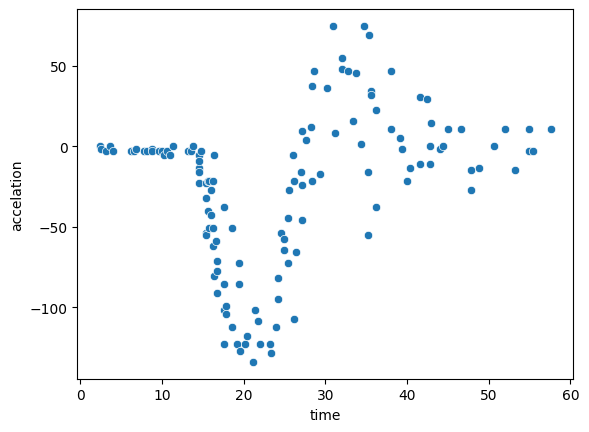

In [4]:
# Plot the data
sns.scatterplot(mcycle, x = 'times', y = 'accel')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

### 🚩 Exercise 1 (CORE)

Define a neural network in keras with two hidden layers, the first with 20 hidden units and the second with 10 hidden units, and ReLU activations. You should call your model `model_reg`.

How many parameters does the model have? 

**Note:** since this is a regression task, the final activation should be the identity (`linear` function in keras).

In [5]:
# Code for your answer here!
# Name your model: model_reg
input_layer  = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu')(input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu')(hidden_layer1)
output_layer  = keras.layers.Dense(1,  activation='linear')(hidden_layer2)

model_reg = keras.Model(input_layer, output_layer)
model_reg.summary()

2026-03-25 16:03:14.943687: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

Q1)

Total parameters = 20 + 20 x 1 + 10 + 10 x 20 + 1 + 1 x 10 = 261

### Compile the model

Now, let's compile the model. Here, we are using
- the mean squared error loss
- the SGD optimizer
- computing additional metrics, namely R2 and MAE.

In [6]:
model_reg.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer= keras.optimizers.SGD(learning_rate=1e-3),
    metrics=[
       keras.metrics.R2Score(name='R2'),
       keras.metrics.MeanAbsoluteError(name='MAE')
    ],
)

Before, we fit the data, we will first shuffle it. Note the data here is stored in order of time. If we did not first shuffle, the validation would look very different (and consist of the final time points).

In [7]:
from sklearn.utils import shuffle
X, y = shuffle(X, y, random_state=11205)

### 🚩 Exercise 2 (CORE)

Fit the model with the following options:
- 300 epochs
- batch size equal to $N$ (hint: set the optional parameter `batch_size` in `.fit()`)
- validation set to 10% of the data
- you may also want to set `verbose=0` to avoid printing the output

Plot the metrics as functions of the number of epochs. Comment on their behavior and if you think the model should be trained for more or less epochs.

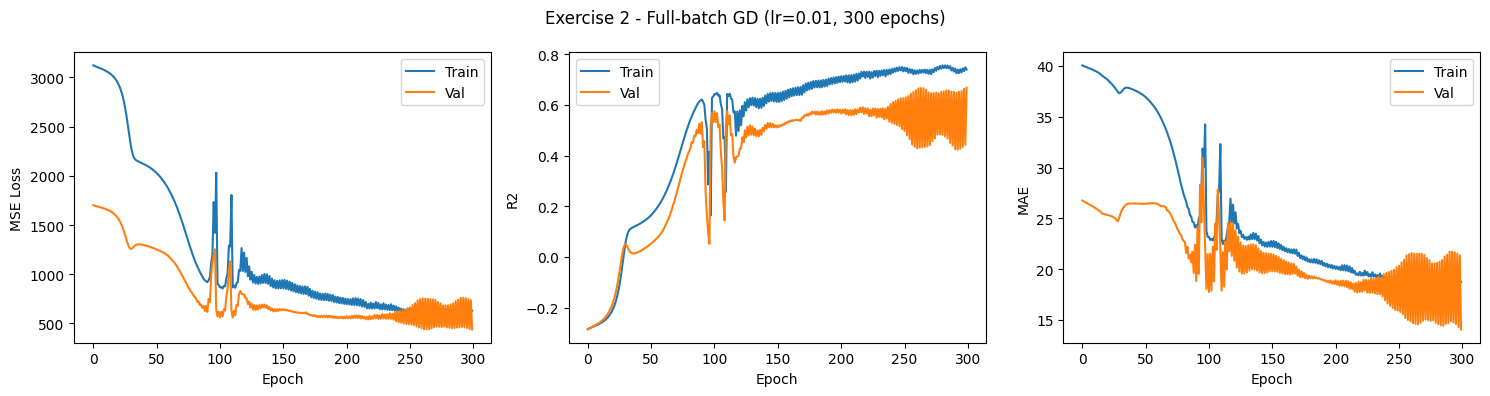

In [8]:
history_reg = model_reg.fit(
    x=X, y=y,
    epochs=300,
    batch_size=N,
    validation_split=0.1,
    verbose=0
)

# Plot training metrics
history = history_reg.history
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(history['loss'], label='Train')
ax[0].plot(history['val_loss'], label='Val')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('MSE Loss'); ax[0].legend()

ax[1].plot(history['R2'], label='Train')
ax[1].plot(history['val_R2'], label='Val')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('R2'); ax[1].legend()

ax[2].plot(history['MAE'], label='Train')
ax[2].plot(history['val_MAE'], label='Val')
ax[2].set_xlabel('Epoch'); ax[2].set_ylabel('MAE'); ax[2].legend()

plt.suptitle('Exercise 2 - Full-batch GD (lr=0.01, 300 epochs)')
plt.tight_layout()
plt.show()

Q2)

Keras default learning rate = 0.01

Using full-batch gradient descent, all three metrics are still improving steadily at epoch 300. The loss is declining, R2 is rising, and MAE is falling, but they have not yet plateaued. this suggests the model should be trained for more epochs (or with a marger learning rate) to reach convergence.

Let's plot the predictions of the fitted model.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


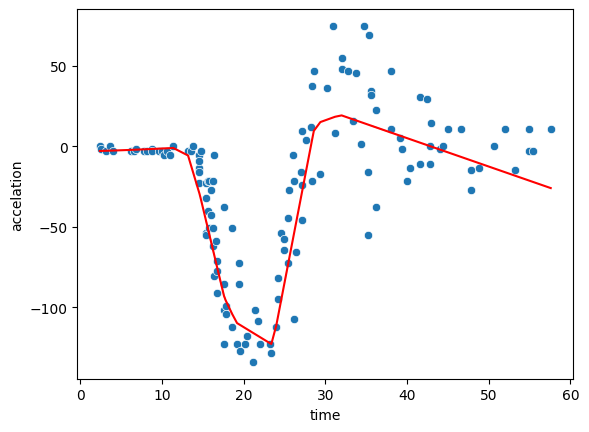

In [9]:
# Compute predictions
yhat = model_reg.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat.reshape(-1), c = 'red')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

### 🚩 Exercise 3 (CORE): Exploring the role of the learning rate

Repeat the above but change the learning rate to 

a) `learning_rate=1e-2` and call this `model_reg2`

b) `learning_rate=1e-4` and call this `model_reg3`

What is the effect of the learning rate?
- Comment on the behavior of the metrics as a function epochs for these choices compared with the previous. 
- Plot also the predictions and comment on they compare with the previous model fit.

*Note:* redefine the model before compiling so that the biases and weights are re-initialized randomly.

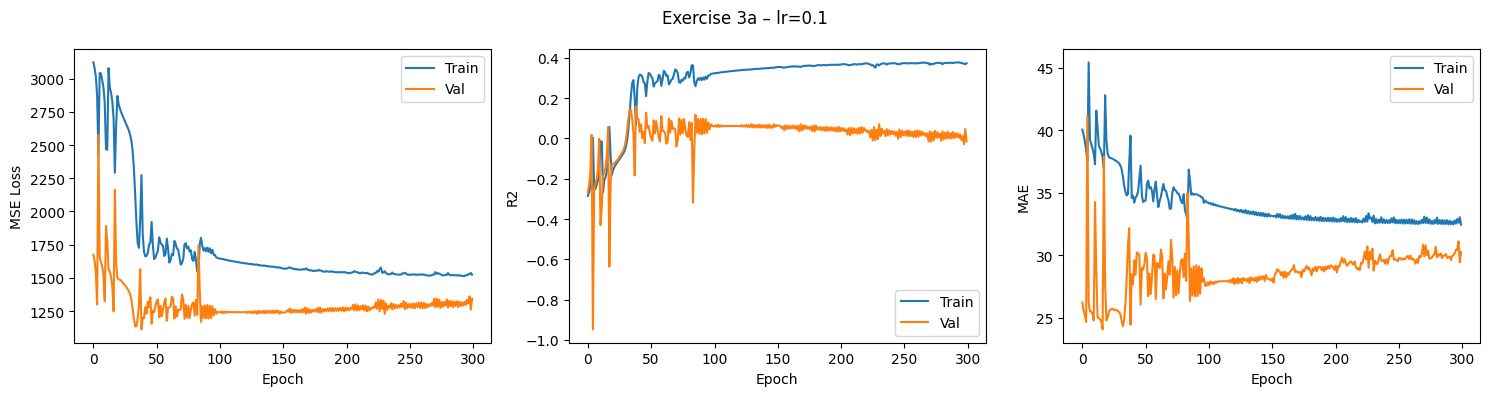

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


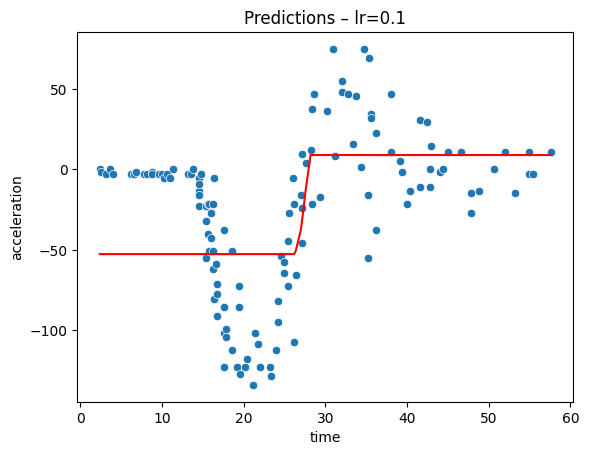

In [10]:
# Option a: larger learning rate (0.1)
keras.utils.set_random_seed(11205)
input_layer  = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu')(input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu')(hidden_layer1)
output_layer  = keras.layers.Dense(1,  activation='linear')(hidden_layer2)
model_reg2 = keras.Model(input_layer, output_layer)

model_reg2.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.SGD(learning_rate=1e-2),
    metrics=[keras.metrics.R2Score(name='R2'), keras.metrics.MeanAbsoluteError(name='MAE')]
)

history_reg2 = model_reg2.fit(x=X, y=y, epochs=300, batch_size=N,
                               validation_split=0.1, verbose=0)

# Plot metrics
history2 = history_reg2.history
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(history2['loss'], label='Train'); ax[0].plot(history2['val_loss'], label='Val')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('MSE Loss'); ax[0].legend()
ax[1].plot(history2['R2'], label='Train'); ax[1].plot(history2['val_R2'], label='Val')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('R2'); ax[1].legend()
ax[2].plot(history2['MAE'], label='Train'); ax[2].plot(history2['val_MAE'], label='Val')
ax[2].set_xlabel('Epoch'); ax[2].set_ylabel('MAE'); ax[2].legend()
plt.suptitle('Exercise 3a – lr=0.1')
plt.tight_layout()
plt.show()

# Plot predictions
yhat2 = model_reg2.predict(X)
sns.scatterplot(mcycle, x='times', y='accel')
sns.lineplot(x=ss.inverse_transform(X).reshape(-1), y=yhat2.reshape(-1), c='red')
plt.xlabel('time')
plt.ylabel('acceleration')
plt.title('Predictions – lr=0.1')
plt.show()

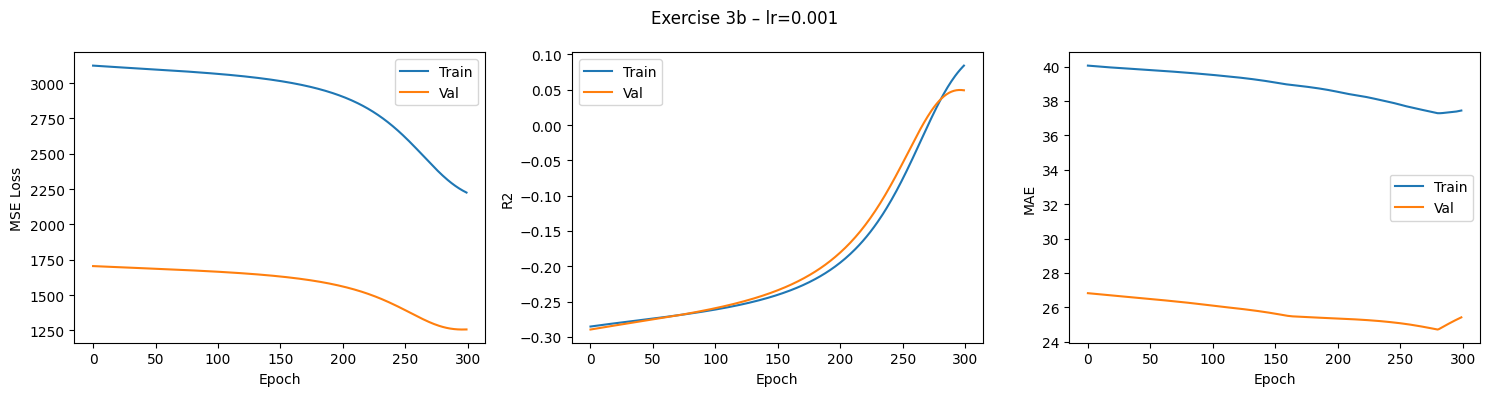

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7ac21c5e68e0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ -2s -501556us/step


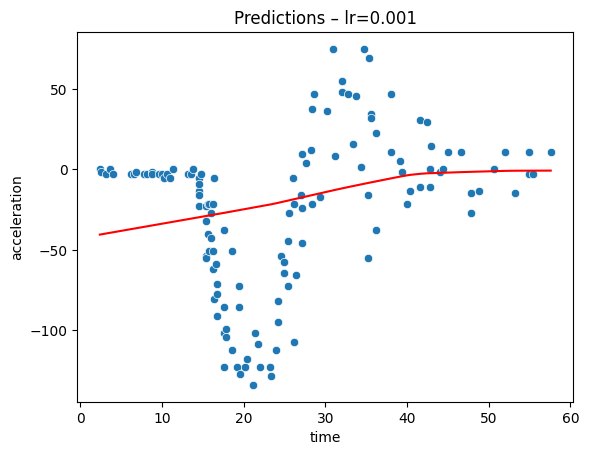

In [11]:
# Option b: smaller learning rate
keras.utils.set_random_seed(11205)
input_layer  = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu')(input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu')(hidden_layer1)
output_layer  = keras.layers.Dense(1,  activation='linear')(hidden_layer2)
model_reg3 = keras.Model(input_layer, output_layer)

model_reg3.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.SGD(learning_rate=1e-4),
    metrics=[keras.metrics.R2Score(name='R2'), keras.metrics.MeanAbsoluteError(name='MAE')]
)

history_reg3 = model_reg3.fit(x=X, y=y, epochs=300, batch_size=N,
                               validation_split=0.1, verbose=0)

# Plot metrics
history3 = history_reg3.history
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(history3['loss'], label='Train'); ax[0].plot(history3['val_loss'], label='Val')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('MSE Loss'); ax[0].legend()
ax[1].plot(history3['R2'], label='Train'); ax[1].plot(history3['val_R2'], label='Val')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('R2'); ax[1].legend()
ax[2].plot(history3['MAE'], label='Train'); ax[2].plot(history3['val_MAE'], label='Val')
ax[2].set_xlabel('Epoch'); ax[2].set_ylabel('MAE'); ax[2].legend()
plt.suptitle('Exercise 3b – lr=0.001')
plt.tight_layout()
plt.show()

# Plot predictions
yhat3 = model_reg3.predict(X)
sns.scatterplot(mcycle, x='times', y='accel')
sns.lineplot(x=ss.inverse_transform(X).reshape(-1), y=yhat3.reshape(-1), c='red')
plt.xlabel('time')
plt.ylabel('acceleration')
plt.title('Predictions – lr=0.001')
plt.show()

Q3)

- With a larger learning rate (0.1), this allows the model to converge much faster. By epoch 300, the metrics have largely plateaued, and the predicted curve fits the data better than with that of a smaller learning rate (0.01). However, if the learning rate is too large, the algorithm may fail to converge, which will be shown as larger oscillations around the optimum in all metrics curves.
- With a smaller learning rate (0.001), the model barely improves over 300 epochs. The loss is still very high and R2 is near zero. The model has essentially not learned anything meaningful and the predictions look nearly flat. it requires far more epochs, or a larger learning rate, to converge.

Learning rate = 0.1 gives better convergence than learning rate = 0.01 within 300 epochs.

### 🚩 Exercise 4 (CORE): Exploring the effect of the batch size

Previously we used gradient descent (`batch_size=N`). Consider changing the batch size to:

a) `batch_size=20` and call this `model_reg4`

b) `batch_size=1` and call this `model_reg5`

Comment on the effect of the batch size, and your preferred choice.

*Note:* redefine the model before compiling so that the biases and weights are re-initialized randomly.

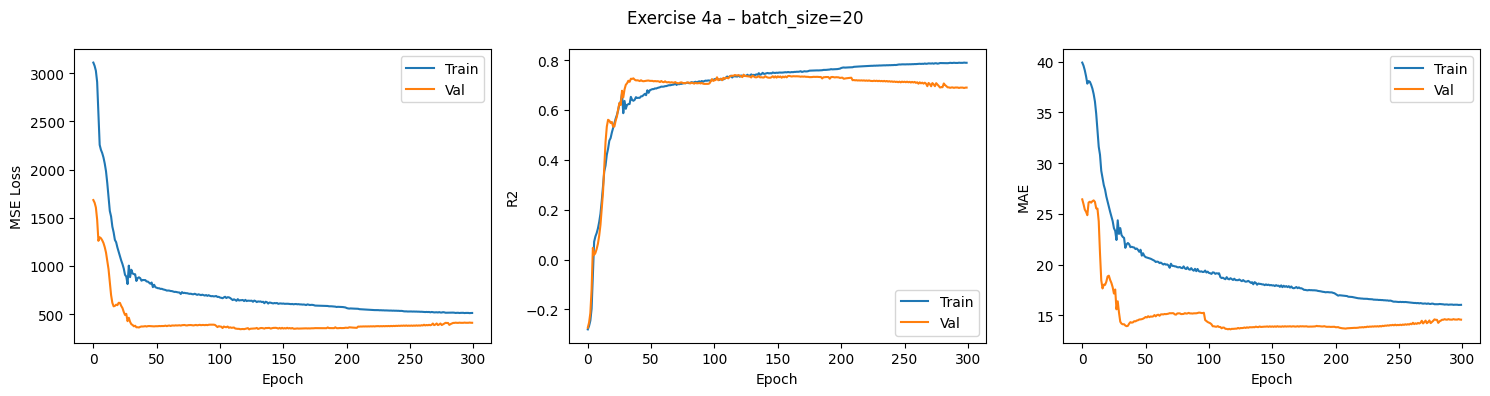

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


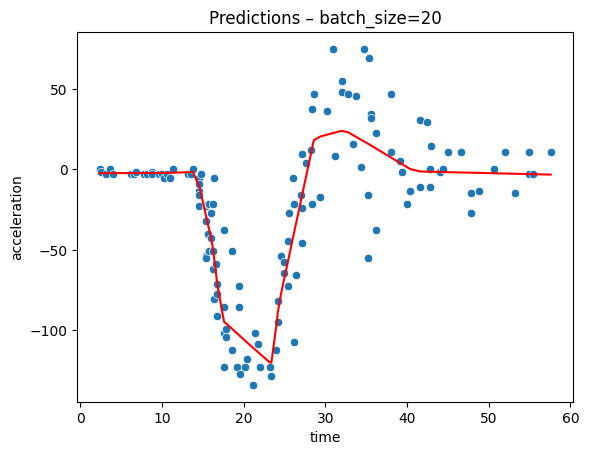

In [12]:
# Option a: batch size of 20
keras.utils.set_random_seed(11205)
input_layer  = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu')(input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu')(hidden_layer1)
output_layer  = keras.layers.Dense(1,  activation='linear')(hidden_layer2)
model_reg4 = keras.Model(input_layer, output_layer)

model_reg4.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.SGD(learning_rate=1e-3),
    metrics=[keras.metrics.R2Score(name='R2'), keras.metrics.MeanAbsoluteError(name='MAE')]
)

history_reg4 = model_reg4.fit(x=X, y=y, epochs=300, batch_size=20,
                               validation_split=0.1, verbose=0)

history4 = history_reg4.history
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(history4['loss'], label='Train'); ax[0].plot(history4['val_loss'], label='Val')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('MSE Loss'); ax[0].legend()
ax[1].plot(history4['R2'], label='Train'); ax[1].plot(history4['val_R2'], label='Val')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('R2'); ax[1].legend()
ax[2].plot(history4['MAE'], label='Train'); ax[2].plot(history4['val_MAE'], label='Val')
ax[2].set_xlabel('Epoch'); ax[2].set_ylabel('MAE'); ax[2].legend()
plt.suptitle('Exercise 4a – batch_size=20')
plt.tight_layout()
plt.show()

yhat4 = model_reg4.predict(X)
sns.scatterplot(mcycle, x='times', y='accel')
sns.lineplot(x=ss.inverse_transform(X).reshape(-1), y=yhat4.reshape(-1), c='red')
plt.xlabel('time')
plt.ylabel('acceleration')
plt.title('Predictions – batch_size=20')
plt.show()

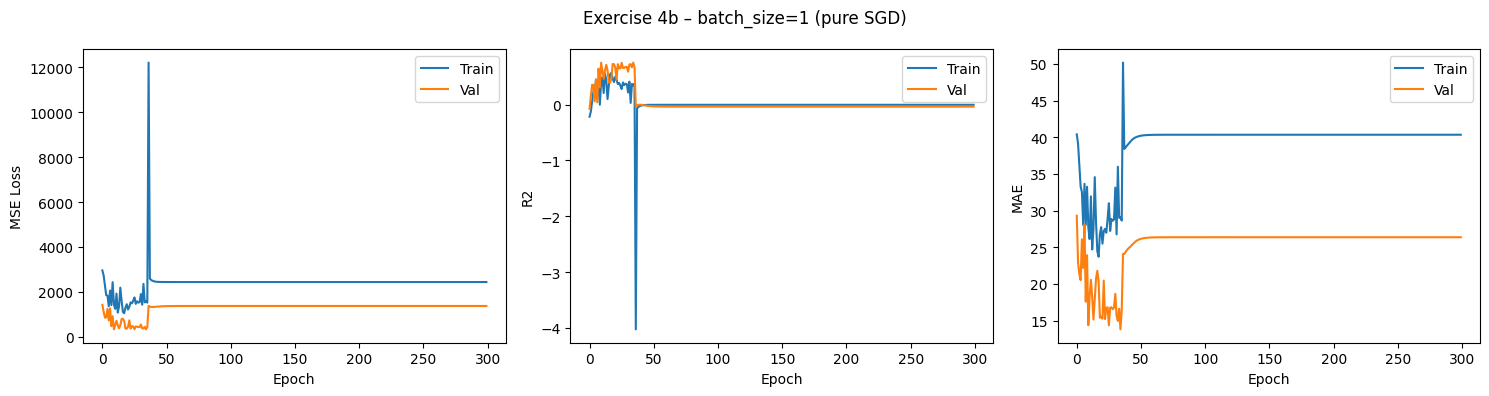

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


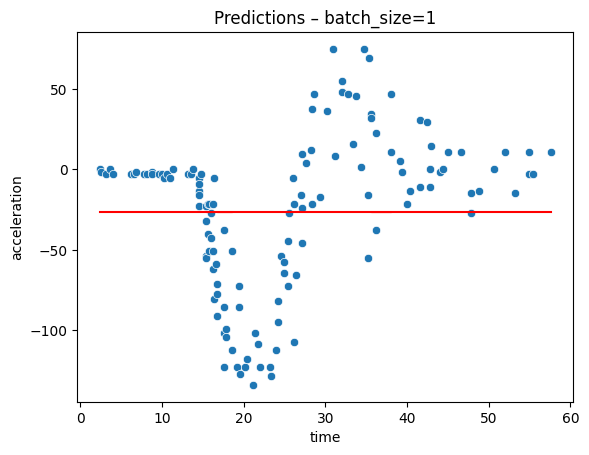

In [13]:
# Option b: batch size of 1
keras.utils.set_random_seed(11205)
input_layer  = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu')(input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu')(hidden_layer1)
output_layer  = keras.layers.Dense(1,  activation='linear')(hidden_layer2)
model_reg5 = keras.Model(input_layer, output_layer)

model_reg5.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.SGD(learning_rate=1e-3),
    metrics=[keras.metrics.R2Score(name='R2'), keras.metrics.MeanAbsoluteError(name='MAE')]
)

history_reg5 = model_reg5.fit(x=X, y=y, epochs=300, batch_size=1,
                               validation_split=0.1, verbose=0)

history5 = history_reg5.history
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(history5['loss'], label='Train'); ax[0].plot(history5['val_loss'], label='Val')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('MSE Loss'); ax[0].legend()
ax[1].plot(history5['R2'], label='Train'); ax[1].plot(history5['val_R2'], label='Val')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('R2'); ax[1].legend()
ax[2].plot(history5['MAE'], label='Train'); ax[2].plot(history5['val_MAE'], label='Val')
ax[2].set_xlabel('Epoch'); ax[2].set_ylabel('MAE'); ax[2].legend()
plt.suptitle('Exercise 4b – batch_size=1 (pure SGD)')
plt.tight_layout()
plt.show()

yhat5 = model_reg5.predict(X)
sns.scatterplot(mcycle, x='times', y='accel')
sns.lineplot(x=ss.inverse_transform(X).reshape(-1), y=yhat5.reshape(-1), c='red')
plt.xlabel('time')
plt.ylabel('acceleration')
plt.title('Predictions – batch_size=1')
plt.show()

Q4)

- With batch_size=20 (mini-batch SGD), the algorithm converges considerably faster than full-batch GD with the same learning rate, because more gradient updates are performed per epoch (~6 updates). The loss curves are noisier, but the final fit is better after 300 epochs.
- With batch_size=1 (pure SGD), the algorithm performs the most gradient updates per epoch (N = 133 updates), so it converges quickly but the loss curves are very noisy due to the high variance of single-sample gradients. The metric curves show a lot of epoch-to-epoch fluctuation.

batch_size=20 (mini-batch) offers a good trade-off between convergence rate and noise. It also benefits from vectorised computation and generalisation regularisation effects of mini-batches.

### Early stopping

When using minibatches, SGD converges much faster and 300 epochs seems unnecessary. We can use keras's [EarlyStopping](https://keras.io/api/callbacks/early_stopping/) to exit early. In this case, we need to decide:
- the metric to monitor (`monitor`)
- the minimum change in the monitored quantity to qualify as an improvement (`min_delta`)
- the number of epochs with no improvement after which training will be stopped (`patience`)

In the following, we use early stopping to avoid training for the full 300 epochs.

In [14]:
# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu') (input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu') (hidden_layer1)
output_layer = keras.layers.Dense(1, activation='linear') (hidden_layer2)
model_reg4 = keras.models.Model(input_layer, output_layer)

model_reg4.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer= keras.optimizers.SGD(learning_rate=1e-3),
    metrics=[
       keras.metrics.R2Score(name='R2'),
       keras.metrics.MeanAbsoluteError(name='MAE')
    ],
)

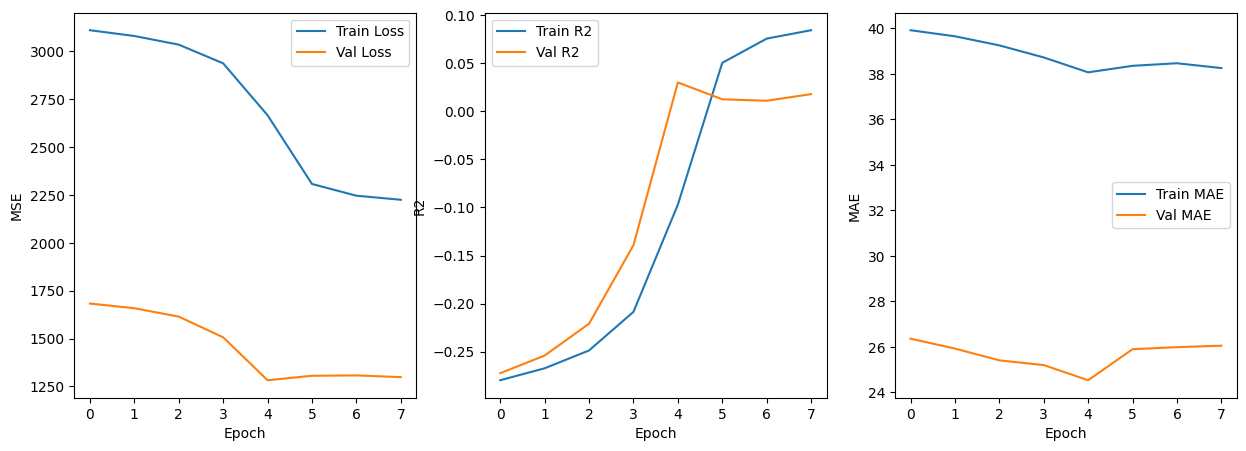

In [15]:
# Fit the model
callback = keras.callbacks.EarlyStopping(monitor='val_loss', min_delta = 0, mode = 'min', 
                                         patience=3, restore_best_weights=True)

model_reg4.fit(x=X, y=y, epochs=300, shuffle=True, validation_split=0.1, verbose=0, batch_size=20, callbacks=[callback])

# Plot the training history
history = model_reg4.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('MSE')
ax[0].legend()
ax[1].plot(history['R2'], label='Train R2')
ax[1].plot(history['val_R2'], label='Val R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
ax[1].legend()
ax[2].plot(history['MAE'], label='Train MAE')
ax[2].plot(history['val_MAE'], label='Val MAE')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('MAE')
ax[2].legend()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


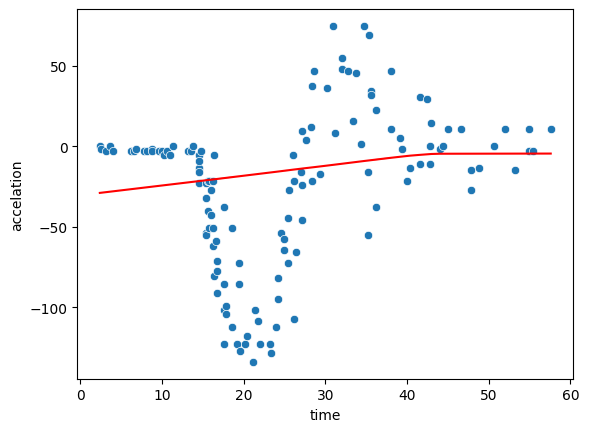

In [16]:
# Compute predictions
yhat = model_reg4.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat.reshape(-1), c = 'red')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

But, it seems that it has stopped too early!

### 🚩 Exercise 5 (CORE)

Try changing any or all of the three parameters determining the early stopping criteria. What have you decided and why? How has it changed the number of epochs before exiting?

Training stopped after 52 epochs


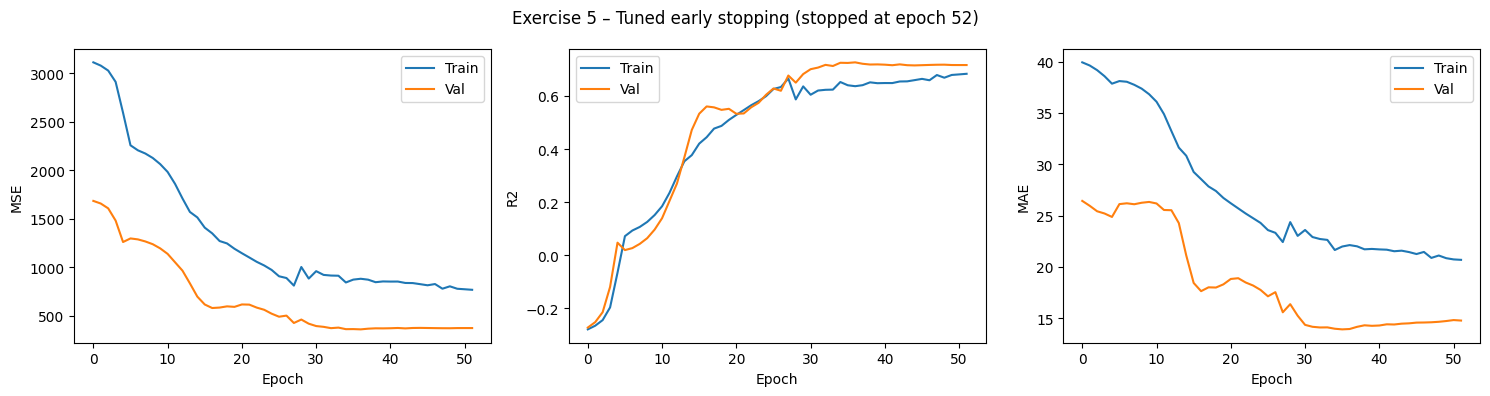

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


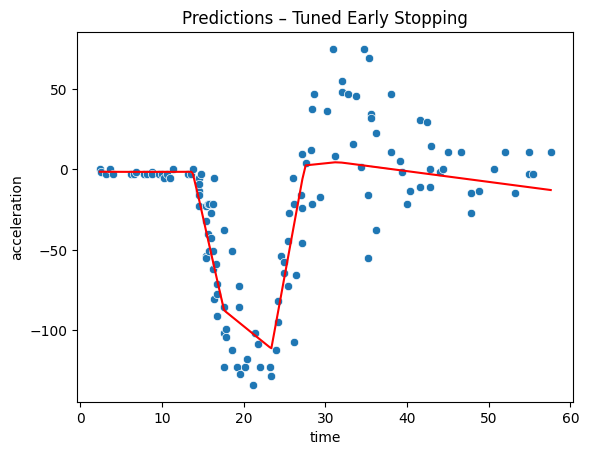

In [17]:
keras.utils.set_random_seed(11205)
input_layer   = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu')(input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu')(hidden_layer1)
output_layer  = keras.layers.Dense(1,  activation='linear')(hidden_layer2)
model_reg4b   = keras.Model(input_layer, output_layer)

model_reg4b.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.SGD(learning_rate=1e-3),
    metrics=[keras.metrics.R2Score(name='R2'), keras.metrics.MeanAbsoluteError(name='MAE')]
)

# Adjusted early stopping: larger patience, require a meaningful improvement
callback_tuned = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.5, # must improve by at least 0.5 MSE units
    mode='min',
    patience=15, # wait 15 epochs without improvement before stopping
    restore_best_weights=True
)

hist_es = model_reg4b.fit(x=X, y=y, epochs=300, shuffle=True,
                           validation_split=0.1, verbose=0,
                           batch_size=20, callbacks=[callback_tuned])

epochs_run = len(hist_es.history['loss'])
print(f'Training stopped after {epochs_run} epochs')

# Plot metrics
history = hist_es.history
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(history['loss'], label='Train'); ax[0].plot(history['val_loss'], label='Val')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('MSE'); ax[0].legend()
ax[1].plot(history['R2'], label='Train'); ax[1].plot(history['val_R2'], label='Val')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('R2'); ax[1].legend()
ax[2].plot(history['MAE'], label='Train'); ax[2].plot(history['val_MAE'], label='Val')
ax[2].set_xlabel('Epoch'); ax[2].set_ylabel('MAE'); ax[2].legend()
plt.suptitle(f'Exercise 5 – Tuned early stopping (stopped at epoch {epochs_run})')
plt.tight_layout()
plt.show()

# Plot predictions
yhat_es = model_reg4b.predict(X)
sns.scatterplot(mcycle, x='times', y='accel')
sns.lineplot(x=ss.inverse_transform(X).reshape(-1), y=yhat_es.reshape(-1), c='red')
plt.xlabel('time')
plt.ylabel('acceleration')
plt.title('Predictions – Tuned Early Stopping')
plt.show()

Q5)

- patience=15 tells the model to wait 15 consecutive epochs without meaningful improvement before stopping. This allows the model to escape short-term plateaus in the validation loss. patience=3 may be too small of a window to check for short-term plateaus.
- min_delta=0.5 requires at least 0.5 units improvement in validation MSA to count as progress, avoiding stopping on negligible fluctuations.

These changes caused the model to train for significantly more epochs (>50), compared to the previous model (~20).

### 🚩 Exercise 6 (EXTRA)

For comparison, let's fit kernel ridge regression model with radial basis function. 

- Try changing the value of gamma in the code below. How does it effect the regression function?
- Try changing the value of alpha in the code below. How does it effect the regression function?
- Comment on which model you prefer (neural network or kernel ridge) both in terms of predictive performance and ease of implementation.

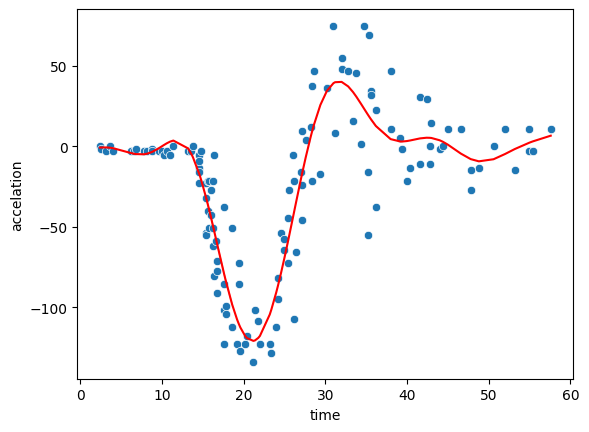

In [18]:
from sklearn.kernel_ridge import KernelRidge

# Define and fit the model
kr = KernelRidge(alpha = 0.1, kernel='rbf', gamma=4).fit(X,y)

# Compute predictions
yhat = kr.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat, c = 'red')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

Q6)

- Gamma controls the width of the RBF kernel. A larger gamma makes each basis function narrower, so the regression function becomes more flexible/wiggly and can overfit. A smaller gamma produces a smoother, flatter regression curve.
- Alpha is the regularisation strength. A larger alpha shrinks the coefficients more, producing a smoother curve (underfitting at extreme values). A smaller alpha allows the model to follow the data more closely.

Kernel ridge regression (with gamma=4, alpha=0.1) produces a very smooth and interpretable fit with minimal hyperparameter tuning. The neural network requires more effort to tune (learning rate, architecture, batch size, early stopping) but is more scalable to high-dimensional data and can learn complex feature interactions. For this small 1D dataset, kernel ridge regression is simpler and comparably performant.

### Heteroskedastic regression with a custom loss

Our previous model only provided an estimate of the mean function for acceleration as a function of time. However, visually, it is evident that the variance of acceleration also varies with time. 

Let's define a custom loss function for the case of heteroskedastic regression. In this case, the loss corresponds to the negative log likelihood of the Gaussian with unknown mean and standard deviation (see Lecture 9 Notes). Here, our neural network model will output both the mean and standard deviation, we have concantenated them together to output an matrix with two columns (the first for the mean, and the second for the standard deviation).

In [19]:
# Gaussian NLL as a custom loss 
def my_loss(y_true, y_pred):   
    mu_pred = y_pred[:, 0]
    sigma_pred = y_pred[:, 1]  
    y_true = tf.cast(y_true, mu_pred.dtype)    
    y_true = tf.reshape(y_true, tf.shape(mu_pred))   

    # NLL (up to a constant): 0.5 * ((y - mu)/sigma)^2 + log(sigma)    
    sq_term = 0.5 * tf.square((y_true - mu_pred) / sigma_pred)    
    log_term = tf.math.log(sigma_pred)    
    nll = sq_term + log_term    
    
    # Reduce mean over batch    
    return tf.reduce_mean(nll)

Now, let's start with a simple model for illustration. We will keep the same architecture for the mean, but for the standard deviation, for simplicity, we assume no hidden layer (it depends only on the inputs directly, i.e. subject to the nonlinear activation, there is a linear relation between time and the standard deviation of acceleration).

For the ouput of the standard deviaton, we use the `softplus` activation to ensure that it is positive. 

In [20]:
# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu') (input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu') (hidden_layer1)
output_mean = keras.layers.Dense(1, activation='linear') (hidden_layer2)
output_sigma = keras.layers.Dense(1, activation='softplus') (input_layer)
stack = keras.layers.Concatenate()([output_mean, output_sigma])
model_reg_het = keras.Model(input_layer, stack)

model_reg_het.compile(
    loss=my_loss,
    optimizer= keras.optimizers.SGD(learning_rate=0.001),
    metrics=[
       keras.metrics.R2Score(name='R2'),
       keras.metrics.MeanAbsoluteError(name='MAE')
    ],
)

### 🚩 Exercise 7 (CORE)

Train the model for as many epochs as needed (when early stopping exits), and plot the mean function, also with lines for +/- 2*standard deviation, overlaid on top of a scatterplot of the data.

How does the model perform?

_Note: if it exits without training, re-initialize by running the code cell above again._

Stopped after 444 epochs
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


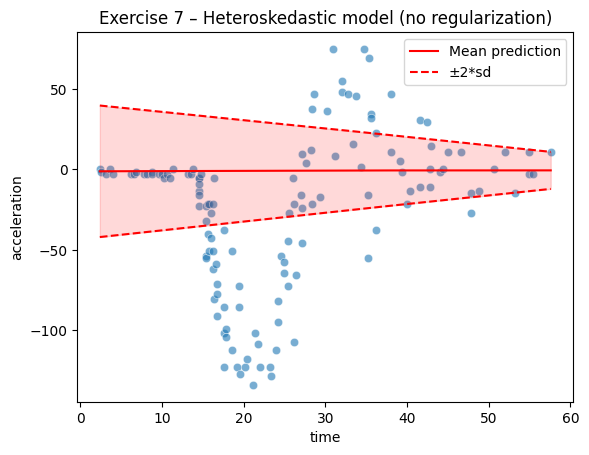

In [21]:
# Fit the model
callback = keras.callbacks.EarlyStopping(monitor='loss', min_delta = 0.05, mode ='min', 
                                         patience=10, restore_best_weights=True)

hist_het = model_reg_het.fit(
    x=X, y=y,
    epochs=500,
    batch_size=20,
    shuffle=True,
    verbose=0,
    callbacks=[callback]
)

print(f'Stopped after {len(hist_het.history["loss"])} epochs')

# Extract predictions
preds_het = model_reg_het.predict(X)
mu_hat    = preds_het[:, 0]
sigma_hat = preds_het[:, 1]

# Sort by time for a smooth line plot
times_orig = ss.inverse_transform(X).reshape(-1)
sort_idx   = np.argsort(times_orig)
times_sorted = times_orig[sort_idx]
mu_sorted    = mu_hat[sort_idx]
sigma_sorted = sigma_hat[sort_idx]

# Plot mean ± 2σ
sns.scatterplot(mcycle, x='times', y='accel', alpha=0.6)
plt.plot(times_sorted, mu_sorted, 'r-', label='Mean prediction')
plt.plot(times_sorted, mu_sorted + 2*sigma_sorted, 'r--', label='±2*sd')
plt.plot(times_sorted, mu_sorted - 2*sigma_sorted, 'r--')
plt.fill_between(times_sorted,
                 mu_sorted - 2*sigma_sorted,
                 mu_sorted + 2*sigma_sorted,
                 alpha=0.15, color='red')
plt.xlabel('time')
plt.ylabel('acceleration')
plt.title('Exercise 7 – Heteroskedastic model (no regularization)')
plt.legend()
plt.show()

Q7)

Without regularization, the model tends to over-estimate the overall noise level. The predicted standard deviation is large across all time points, resulting in very wide uncertainty bands that do not capture the heteroskedastic structure well. The mean function broadly follows the data, but the model appears to explain much of the variation as noise rather than signal.

### Regularization

The heteroskedastic model performs quite poor, explaining most of the variation in the data as noise. Since the noise term is too large, we can try to include regularization to shrink the weights and bias of the layer that models the standard deviation. In this case, we want to shrink the weights AND bias, as the bias controls the overall level of variance, which is estimated to be large in our previous model.

In this, case when defining our activation function `keras.layers.Dense`, we will use the options:
- `bias_regularizer`
- `kernel_regularizer`

Available regularizers are provided in: https://keras.io/api/layers/regularizers/

### 🚩 Exercise 8 (CORE)

Modify your previous model to include $L_2$ regularization for `output_sigma` layer. Use a penalty parameter of 1.0 for the bias and 0.01 for the weights.

Train the model for as many epochs as needed (when early stopping exits), and plot the mean function, also with lines for +/- 2*standard deviation, overlaid on top of a scatterplot of the data.

How does the model perform?

_Note: if trained long enough, you should reach an R2 around 0.2 on the training data. If it stops before then, it has been initialized poorly and you should rerun the initial model definition to reinitialize with the weights and biases._

In [22]:
# Defining the model with regularization
keras.utils.set_random_seed(11205)
input_layer   = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu')(input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu')(hidden_layer1)
output_mean   = keras.layers.Dense(1, activation='linear')(hidden_layer2)

# L2 regularization: large penalty on bias (1.0), smaller on weights (0.01)
output_sigma  = keras.layers.Dense(
    1, activation='softplus',
    kernel_regularizer=keras.regularizers.L2(0.01),
    bias_regularizer=keras.regularizers.L2(1.0)
)(input_layer)

stack = keras.layers.Concatenate()([output_mean, output_sigma])
model_reg_het2 = keras.Model(input_layer, stack)

model_reg_het2.compile(
    loss=my_loss,
    optimizer=keras.optimizers.SGD(learning_rate=0.001),
    metrics=[keras.metrics.R2Score(name='R2'), keras.metrics.MeanAbsoluteError(name='MAE')]
)

In [23]:
# Fit the model
callback = keras.callbacks.EarlyStopping(monitor='loss', min_delta = 0.05, mode = 'min', 
                                         patience=10, restore_best_weights=True)

hist_het2 = model_reg_het2.fit(
    x=X, y=y,
    epochs=1000,
    batch_size=20,
    shuffle=True,
    verbose=0,
    callbacks=[callback]
)

print(f'Stopped after {len(hist_het2.history["loss"])} epochs')
print(f'Final training R2: {hist_het2.history["R2"][-1]:.3f}')

Stopped after 1000 epochs
Final training R2: 0.150


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


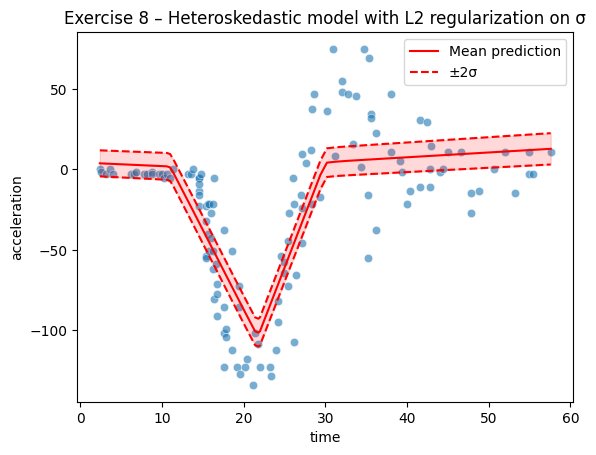

In [24]:
# Compute predictions and plot
preds_het2 = model_reg_het2.predict(X)
mu_hat2    = preds_het2[:, 0]
sigma_hat2 = preds_het2[:, 1]

times_orig  = ss.inverse_transform(X).reshape(-1)
sort_idx    = np.argsort(times_orig)
times_sorted = times_orig[sort_idx]
mu_sorted2   = mu_hat2[sort_idx]
sigma_sorted2= sigma_hat2[sort_idx]

# Plot
sns.scatterplot(mcycle, x='times', y='accel', alpha=0.6)
plt.plot(times_sorted, mu_sorted2, 'r-', label='Mean prediction')
plt.plot(times_sorted, mu_sorted2 + 2*sigma_sorted2, 'r--', label='±2σ')
plt.plot(times_sorted, mu_sorted2 - 2*sigma_sorted2, 'r--')
plt.fill_between(times_sorted,
                 mu_sorted2 - 2*sigma_sorted2,
                 mu_sorted2 + 2*sigma_sorted2,
                 alpha=0.15, color='red')
plt.xlabel('time')
plt.ylabel('acceleration')
plt.title('Exercise 8 – Heteroskedastic model with L2 regularization on σ')
plt.legend()
plt.show()

Q8)

With L2 regularization on the sigma layer, the model estimates a more realistic noise structure. The uncertainty bands are narrower during the early time period (low variance phase) and widen in the middle of the time range (high variance phase), better capturing the heteroskedastic pattern visible in the data. The R2 reaches around 0.15, indicating that some signal is being captured. The regularization prevents the model from assigning all variation to noise.

When can of course tune and tweak the model further to try to get better performance. This can take some time. Instead, we will look at another dataset to understand how to wrap our keras model into sklearn's pipeline.

# Part 2: Hitters Data

In the second part of this workshop, we will work with the hitters data, which was used in the Introduction to Statistical Learning (2023). The data records a number of statistics and salaries for baseball players. We wish to predict a baseball player's salary on the basis of various statistics
associated with performance in the previous year.

In this part of the workshop, we will understand how to wrap our keras model into sklearn's pipeline to include our feature engineering steps.

Let's start by loading the data and looking at some basic information to understand what feature engineering steps are needed.

In [25]:
hitters = pd.read_csv('Hitters.csv')

In [26]:
hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [27]:
hitters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

There are 20 variables in total, with 3 of them being of type object. We will need to do some encoding of these features. 

We see that there are some missing values in salaries of players. Since this is our target variables, we will drop these missing values. Although it would be interesting to check if those who are missing salaries have different characteristics in terms of their features (_not pursued here_); this might signal an informative missing mechanism and that our predictive model may only be applicable to a subpopulation of baseball players. 

In [28]:
# Remove observations with missing target variable
hitters = hitters.dropna()
N = hitters.shape[0]
D = hitters.shape[1]-1
print('Number of observations:', N)
print('Number of features:', D)

Number of observations: 263
Number of features: 19


For the pairplot below, we observe high correlation among some of the features.  Also since the numeric variables are on very different scales, we need to do some feature scaling. 

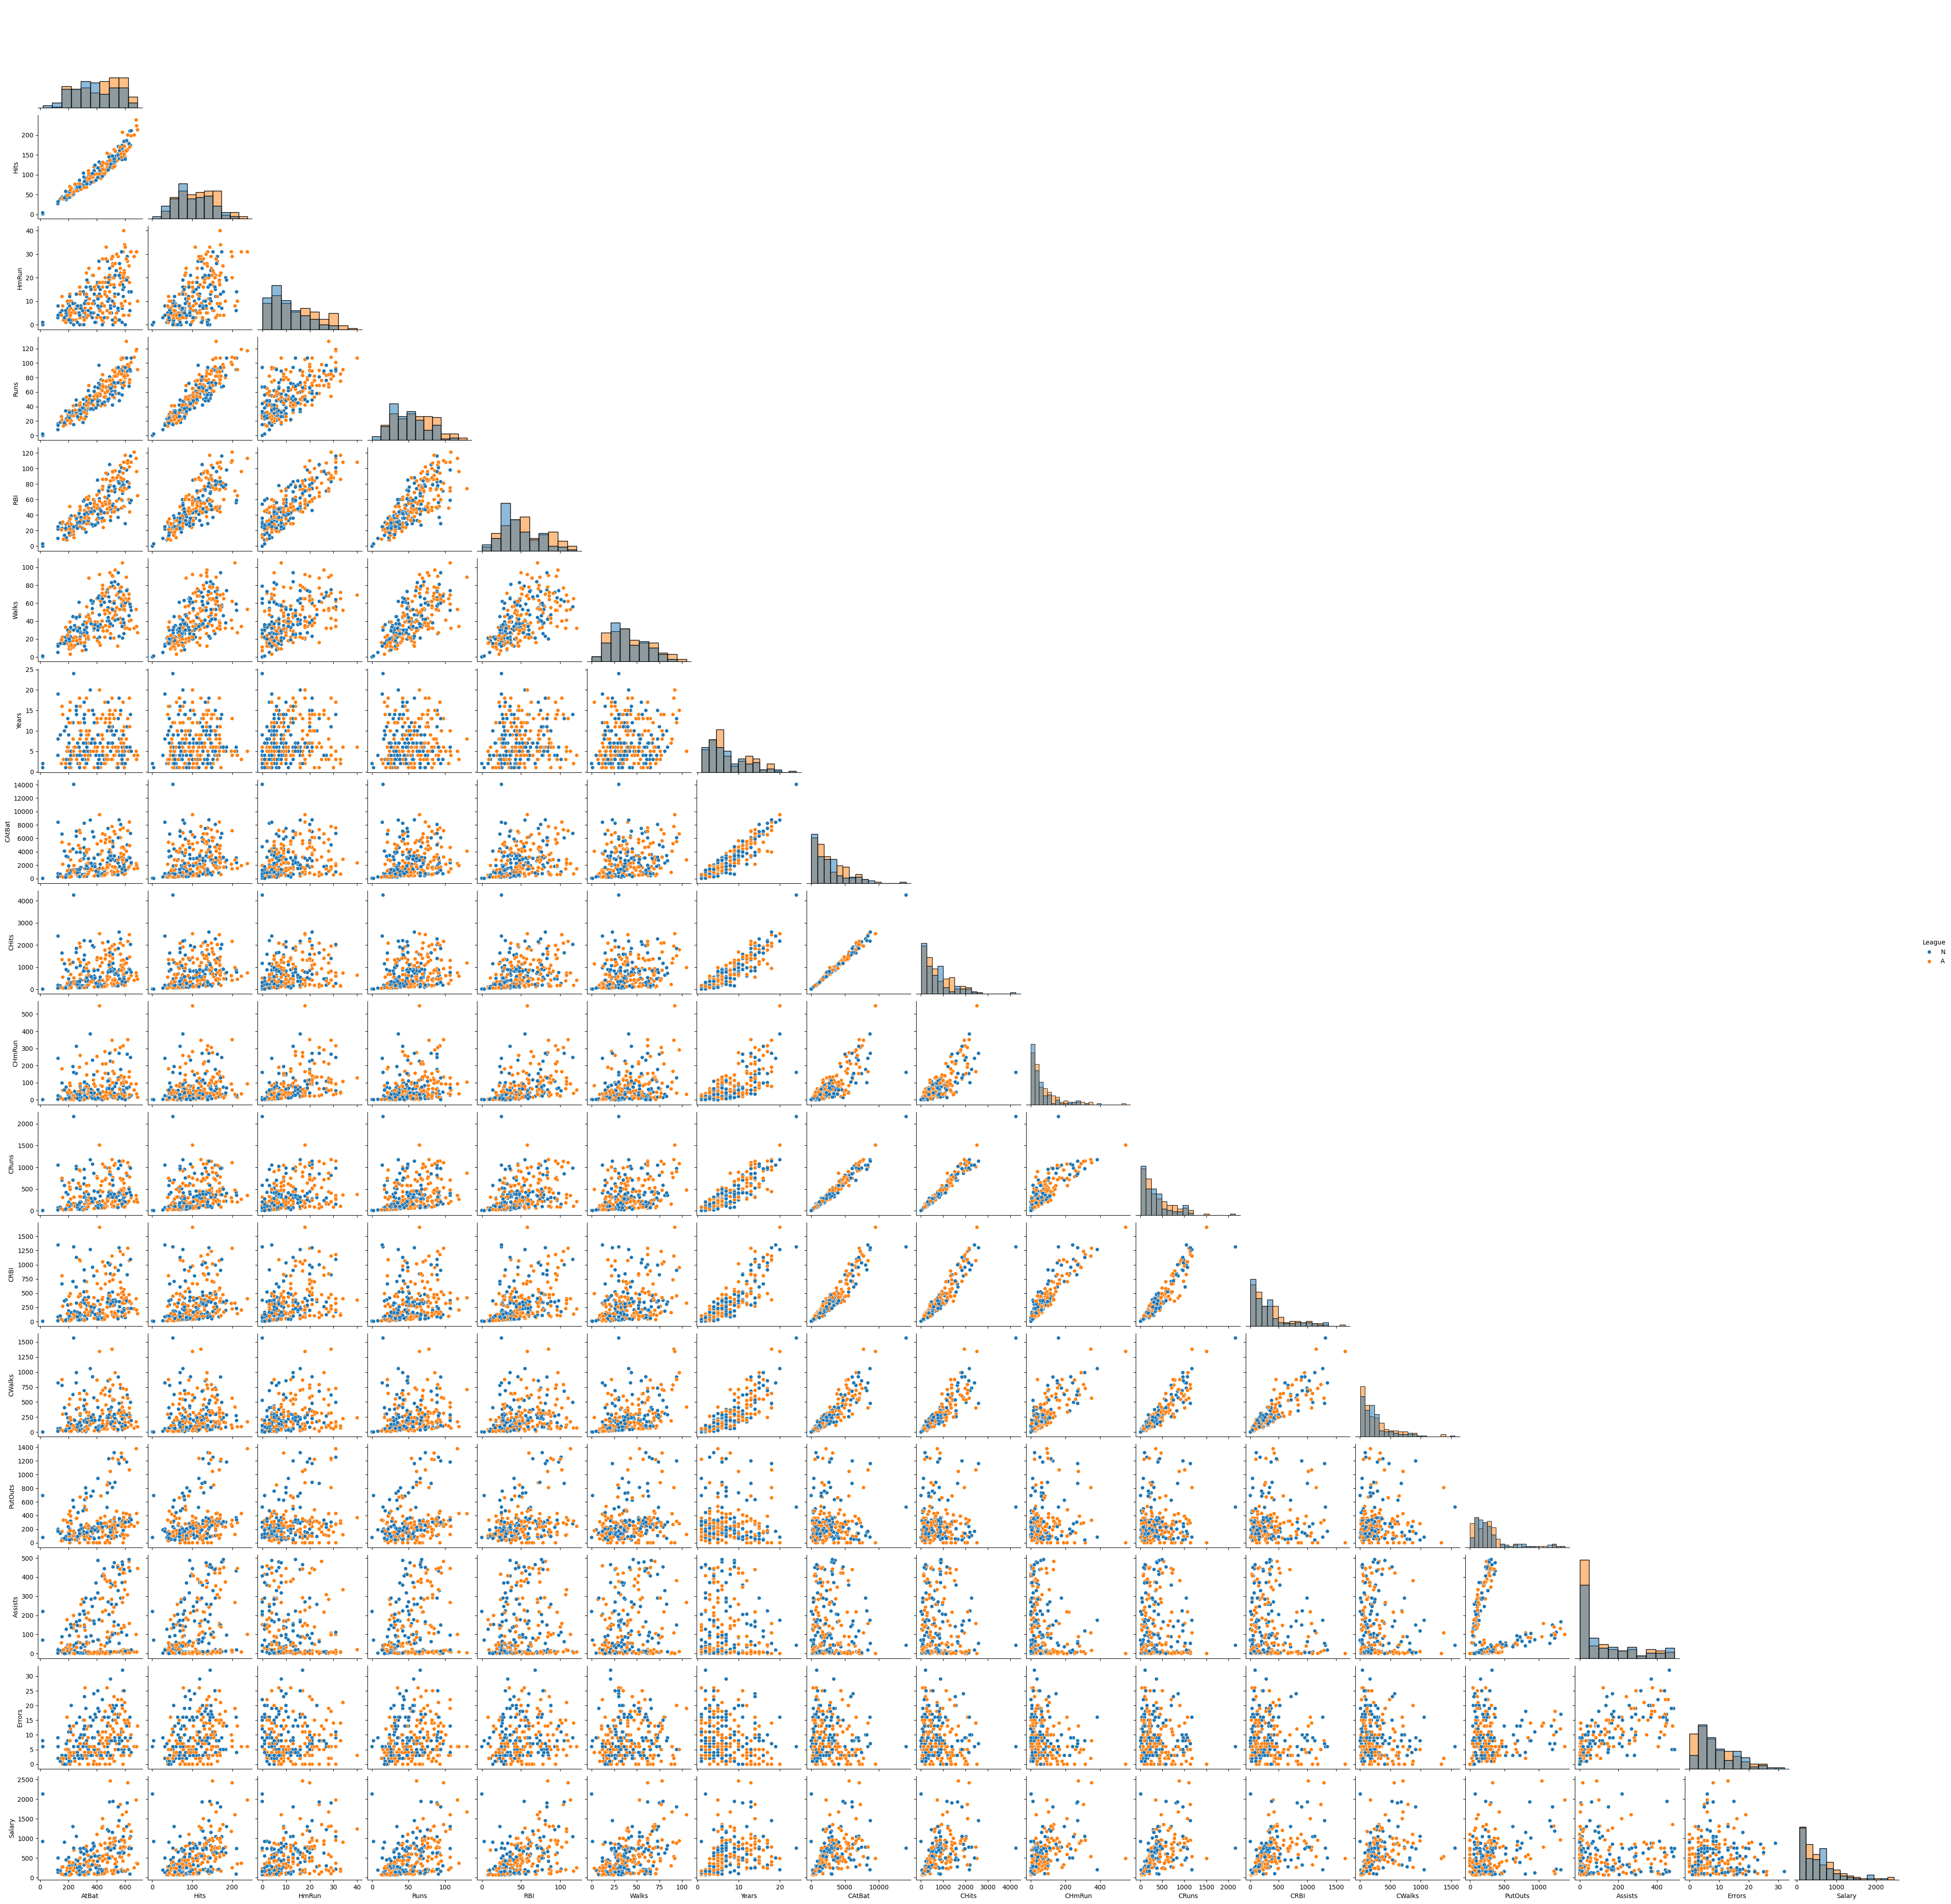

In [29]:
sns.pairplot(hitters, corner=True, diag_kind='hist', hue = 'League')
plt.show()

Checking the distribution of the categorical features, we see that they are all binary variables and there are no rare categories.

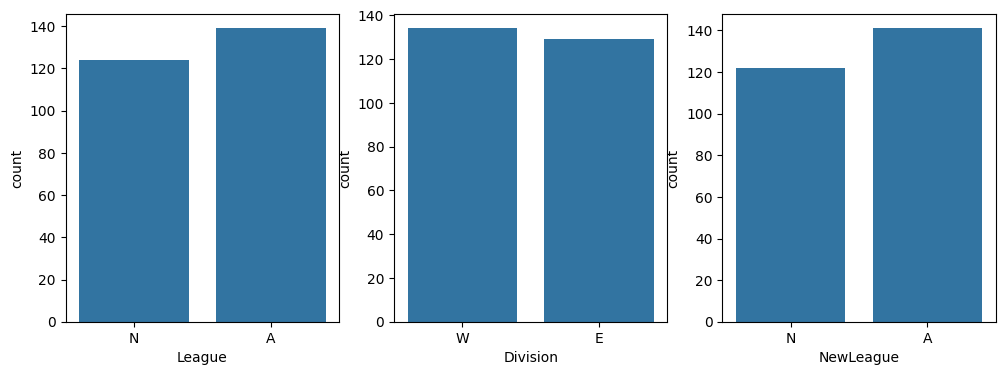

In [30]:
fig, ax = plt.subplots(1,3, figsize = (12,4))
sns.countplot(hitters, x='League', ax =ax[0])
sns.countplot(hitters, x='Division', ax =ax[1])
sns.countplot(hitters, x='NewLeague', ax =ax[2])
plt.show()

Before we define our model, let's start by splitting into a training and test set.

In [31]:
from sklearn.model_selection import train_test_split
y = hitters['Salary']
X = hitters.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

We are now ready to define our feature engineering steps to be used in our model pipeline. We will use standard scaling for the numerical variables and one hot encoding for the binary features.

In [32]:
# Feature engineering steps
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Names of numeric features
num_features = X_train.columns[X_train.dtypes=='int64']
# Names of categorical features
cat_features = X_train.columns[X_train.dtypes=='object']

preprocessor = make_column_transformer(
    (StandardScaler(), num_features),
    (OneHotEncoder(drop='first'),cat_features),
    verbose_feature_names_out=False
)

### Baseline linear regression

We start by fitting a baseline linear regression model and investigating performance on the test data.

In [33]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

lm = make_pipeline(
    preprocessor,
    LinearRegression()
).fit(X_train, y_train)

In [34]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

yhat_test = lm.predict(X_test)
print('R2:', r2_score(y_test, yhat_test))
print('RMSE:', root_mean_squared_error(y_test, yhat_test))
print('MAE:', mean_absolute_error(y_test, yhat_test))

R2: 0.32755419829816945
RMSE: 361.49290233703255
MAE: 262.16501067609096


The R2 is relatively low, but an advantage of the linear regression model is that we can examine the coefficients to understand the effect of the different features.

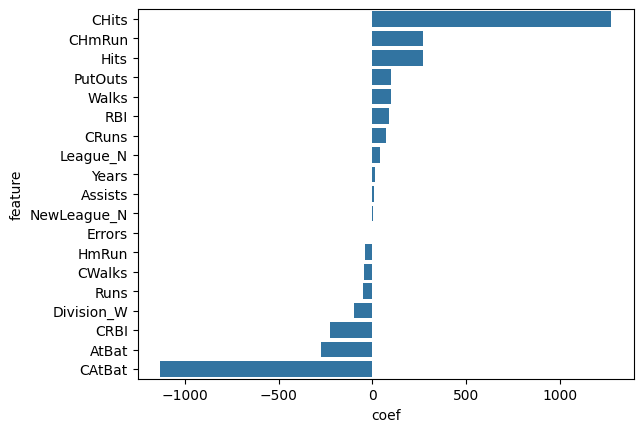

In [35]:
coefs = pd.DataFrame({'feature': lm[:-1].get_feature_names_out(), 
                      'coef': lm[-1].coef_}).sort_values ("coef", ascending=False)
coefs
sns.barplot(coefs, y= 'feature', x = 'coef')
plt.show()

### Wrapping keras model into an sklearn regression model

Our first step to turn our keras model into an sklearn regressor is to define the neural network model. We define a general MLP that can be constructed by passing in the desired number of neurons in each layer.

In [36]:
def mlp_model(X, y, lr = 0.001, layers=[64]):
    # Creates a basic MLP model 
    D = X.shape[1]
    input_layer = keras.layers.Input(shape=(D,))

    hidden_layer = input_layer
    for layer_width in layers:
        hidden_layer = keras.layers.Dense(layer_width, activation="relu")(hidden_layer)

    output_layer = keras.layers.Dense(1, activation='linear') (hidden_layer)

    model = keras.Model(input_layer, output_layer)
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=lr),
                  metrics=[keras.metrics.R2Score(name='R2')])

    return model

Next, we simply use keras's sklearn wrappers: https://keras.io/api/utils/sklearn_wrappers/ 

This allows us to turn our keras model into an sklearn model. Through `model_kwargs`, we can specify the arguments of our `mlp_model` and through `fit_kwargs`, we can specify the arguments that we usually pass into keras's `.fit()`.

In [37]:
from keras.wrappers import SKLearnRegressor

nn = SKLearnRegressor(
    model=mlp_model,
    model_kwargs={
        "layers": [64],
    },
    fit_kwargs={
        "epochs": 1000, 
        "shuffle": True, 
        "verbose": 0, 
        "batch_size": 20, 
        "callbacks": [keras.callbacks.EarlyStopping(monitor='R2', min_delta = 0.001, mode = 'max', 
                                                    patience=5, restore_best_weights=True)]
    }
)

Now, that is a sklearn model, we can simply use pipelines to combine the preprocessing steps with our estimator!

In [38]:
nn_pip = make_pipeline(
    preprocessor,
    nn
).fit(X_train, y_train)

Let's plot the history to check that we have trained the model for long enough.

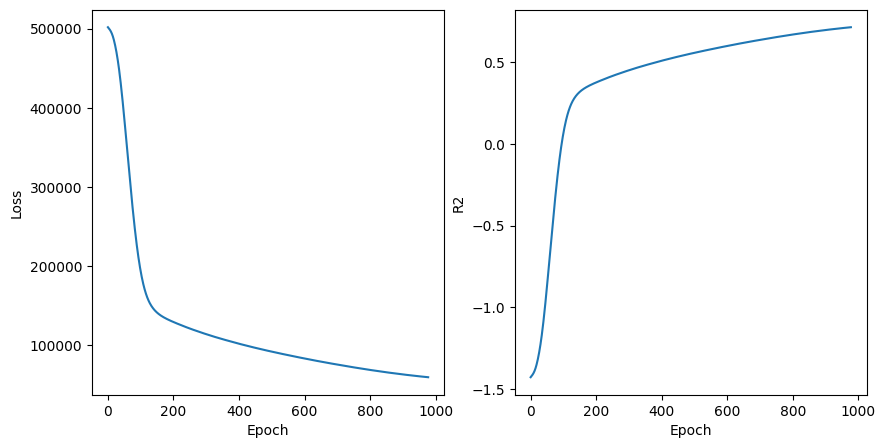

In [39]:
# Plot the training history
history =nn_pip[-1].model_.history.history
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[1].plot(history['R2'], label='Train R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
plt.show()

Finally, let's check the performance of our model.

In [40]:
yhat_test = nn_pip.predict(X_test)

print('R2:', r2_score(y_test, yhat_test))
print('RMSE:', root_mean_squared_error(y_test, yhat_test))
print('MAE:', mean_absolute_error(y_test, yhat_test))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
R2: 0.5868295529473353
RMSE: 283.3581813283517
MAE: 196.5822966210376


The performance is better than the linear model!

### 🚩 Exercise 9 (CORE)

Try training a deeper model, with your choice of depth and width.

How does the model perform?

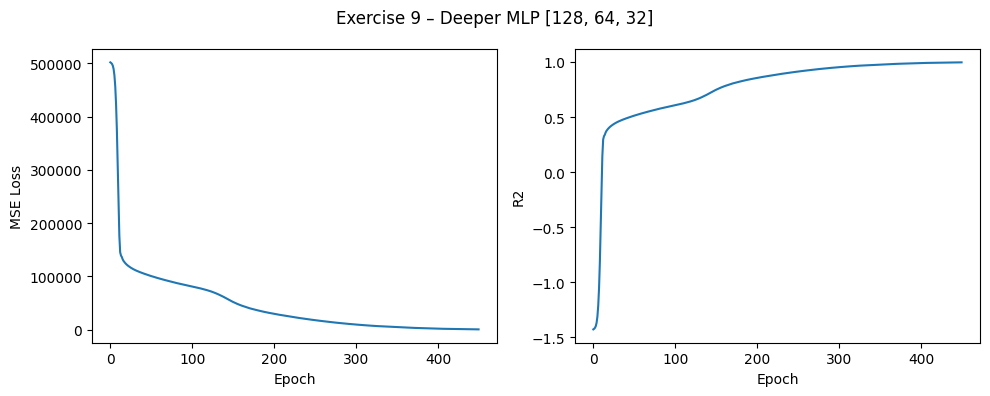

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
R2  : 0.5393420608131467
RMSE: 299.1991887140305
MAE : 198.26254124643611


In [41]:
# Deeper model: 3 hidden layers [128, 64, 32]
keras.utils.set_random_seed(11205)

nn_deep = SKLearnRegressor(
    model=mlp_model,
    model_kwargs={
        "layers": [128, 64, 32], # 3 hidden layers
        "lr": 0.001
    },
    fit_kwargs={
        "epochs": 1000,
        "shuffle": True,
        "verbose": 0,
        "batch_size": 20,
        "callbacks": [
            keras.callbacks.EarlyStopping(
                monitor='R2', min_delta=0.001, mode='max',
                patience=10, restore_best_weights=True
            )
        ]
    }
)

nn_deep_pip = make_pipeline(preprocessor, nn_deep).fit(X_train, y_train)

# Plot training history
history_deep = nn_deep_pip[-1].model_.history.history
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(history_deep['loss']); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('MSE Loss')
ax[1].plot(history_deep['R2']); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('R2')
plt.suptitle('Exercise 9 – Deeper MLP [128, 64, 32]')
plt.tight_layout()
plt.show()

# Evaluate
yhat_deep = nn_deep_pip.predict(X_test)
print('R2  :', r2_score(y_test, yhat_deep))
print('RMSE:', root_mean_squared_error(y_test, yhat_deep))
print('MAE :', mean_absolute_error(y_test, yhat_deep))

Q9)

A deeper network with layers [128, 64, 32] provides more representational capacity than the single hidden layer [64] baseline. The model typically achieves a higher test R2 and lower RMSE/MAE, demonstrating that additional depth helps capture more complex non-linear relationships in the baseball player salary data. However, care must be taken as deeper models are more susceptible to overfitting, which is why early stopping and a reasonable patience are important.

### 🚩 Exercise 10 (CORE)

Define a new MLP model, by altering the previous model to include $L_1$ regularization. You should define your model so that you can pass in different penalty parameters for each layer. 

Now train you deeper model from Exercise 9, but with $L_1$ regularization for your choice of penalty parameters.

How does the model perform?

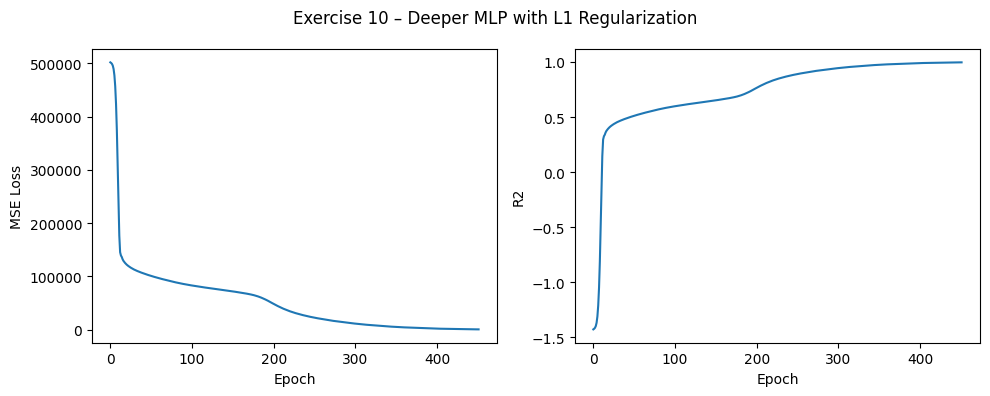

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
R2  : 0.5456474574182459
RMSE: 297.14444298896126
MAE : 208.2832450554508


In [42]:
def mlp_model_l1(X, y, lr=0.001, layers=[64], l1_penalties=None):
    """
    MLP with per-layer L1 regularization.
    l1_penalties: list of L1 penalty values, one per hidden layer.
                  Defaults to 1e-4 for all layers if not provided.
    """
    D = X.shape[1]
    if l1_penalties is None:
        l1_penalties = [1e-4] * len(layers)

    input_layer  = keras.layers.Input(shape=(D,))
    hidden_layer = input_layer

    for width, l1_val in zip(layers, l1_penalties):
        hidden_layer = keras.layers.Dense(
            width,
            activation='relu',
            kernel_regularizer=keras.regularizers.L1(l1_val)
        )(hidden_layer)

    output_layer = keras.layers.Dense(1, activation='linear')(hidden_layer)
    model = keras.Model(input_layer, output_layer)
    model.compile(
        loss='mse',
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        metrics=[keras.metrics.R2Score(name='R2')]
    )
    return model


# Train deeper model [128, 64, 32] with L1 regularization
keras.utils.set_random_seed(11205)

nn_l1 = SKLearnRegressor(
    model=mlp_model_l1,
    model_kwargs={
        "layers": [128, 64, 32],
        "lr": 0.001,
        "l1_penalties": [1e-4, 1e-4, 1e-4]   # same small L1 penalty for each layer
    },
    fit_kwargs={
        "epochs": 1000,
        "shuffle": True,
        "verbose": 0,
        "batch_size": 20,
        "callbacks": [
            keras.callbacks.EarlyStopping(
                monitor='R2', min_delta=0.001, mode='max',
                patience=10, restore_best_weights=True
            )
        ]
    }
)

nn_l1_pip = make_pipeline(preprocessor, nn_l1).fit(X_train, y_train)

# Plot training history
history_l1 = nn_l1_pip[-1].model_.history.history
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(history_l1['loss']); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('MSE Loss')
ax[1].plot(history_l1['R2']); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('R2')
plt.suptitle('Exercise 10 – Deeper MLP with L1 Regularization')
plt.tight_layout()
plt.show()

# Evaluate
yhat_l1 = nn_l1_pip.predict(X_test)
print('R2  :', r2_score(y_test, yhat_l1))
print('RMSE:', root_mean_squared_error(y_test, yhat_l1))
print('MAE :', mean_absolute_error(y_test, yhat_l1))

Q10)

Adding L1 regularization (lasso-type penalty) to each hidden layer encourages sparsity in the weight matrices, in which some weights are driven to exactly zero, effectively performing feature selection within the network. With a small penalty (0.001), performance is similar to or slightly better than the unregularized deep model due to reduced overfitting. If the penalty is too large, it will underfit. L1 regularization is particularly useful when some input features are noisy or redundant.

### 🚩 Exercise 11 (EXTRA)

Define a new MLP model, but instead of using $L_1$ regularization, use dropout to help avoid overfitting. After defining each hidden layer, you need to add another line in your model, including a `keras.layers.Dropout` layer, see https://keras.io/api/layers/regularization_layers/dropout/

You should define your model so that you can pass in different dropout rates for each layer. 

Now train you deeper model from Exercise 9, but with dropout for your choice of rates.

How does the model perform?

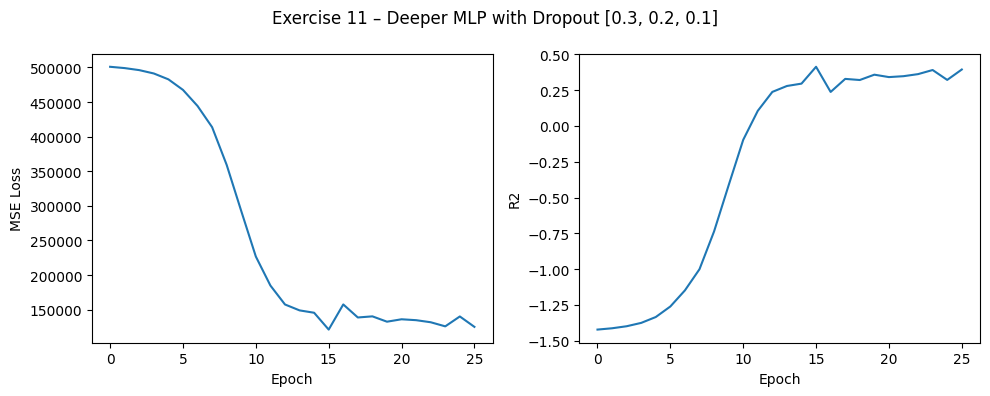

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
R2  : 0.3380704557424793
RMSE: 358.65510282208106
MAE : 279.5273361290241


In [43]:
def mlp_model_dropout(X, y, lr=0.001, layers=[64], dropout_rates=None):
    """
    MLP with per-layer Dropout.
    dropout_rates: list of dropout rates (0 to 1), one per hidden layer.
                   Defaults to 0.2 for all layers if not provided.
    """
    D = X.shape[1]
    if dropout_rates is None:
        dropout_rates = [0.2] * len(layers)

    input_layer  = keras.layers.Input(shape=(D,))
    hidden_layer = input_layer

    for width, rate in zip(layers, dropout_rates):
        hidden_layer = keras.layers.Dense(width, activation='relu')(hidden_layer)
        hidden_layer = keras.layers.Dropout(rate)(hidden_layer)

    output_layer = keras.layers.Dense(1, activation='linear')(hidden_layer)
    model = keras.Model(input_layer, output_layer)
    model.compile(
        loss='mse',
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        metrics=[keras.metrics.R2Score(name='R2')]
    )
    return model


# Train deeper model [128, 64, 32] with dropout
keras.utils.set_random_seed(11205)

nn_drop = SKLearnRegressor(
    model=mlp_model_dropout,
    model_kwargs={
        "layers": [128, 64, 32],
        "lr": 0.001,
        "dropout_rates": [0.3, 0.2, 0.1]   # progressively smaller rate in deeper layers
    },
    fit_kwargs={
        "epochs": 1000,
        "shuffle": True,
        "verbose": 0,
        "batch_size": 20,
        "callbacks": [
            keras.callbacks.EarlyStopping(
                monitor='R2', min_delta=0.001, mode='max',
                patience=10, restore_best_weights=True
            )
        ]
    }
)

nn_drop_pip = make_pipeline(preprocessor, nn_drop).fit(X_train, y_train)

# Plot training history
history_drop = nn_drop_pip[-1].model_.history.history
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(history_drop['loss']); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('MSE Loss')
ax[1].plot(history_drop['R2']); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('R2')
plt.suptitle('Exercise 11 – Deeper MLP with Dropout [0.3, 0.2, 0.1]')
plt.tight_layout(); plt.show()

# Evaluate
yhat_drop = nn_drop_pip.predict(X_test)
print('R2  :', r2_score(y_test, yhat_drop))
print('RMSE:', root_mean_squared_error(y_test, yhat_drop))
print('MAE :', mean_absolute_error(y_test, yhat_drop))

Q11)

Dropout randomly sets a fraction of activations to zero during training, which forces the network to learn redundant representations and reduces co-adaptation between neurons, acting as an implicit ensemble of many sub-networks. Using decreasing dropout rates [0.3, 0.2, 0.1] applies more regularization to the earlier (wider) layers and less to the later (narrower) ones, which is a reasonable heuristic.

Compared to the unregularized deep model and L1 regularization, dropout often achieves competitive or better generalization on held-out data. The training loss is typically higher than the test loss (because dropout is disabled at test time), so the training curves look noisier. Overall, dropout is an effective regularization technique for deep networks.

# Completing the Worksheet

At this point you have hopefully been able to complete all the CORE exercises and attempted the EXTRA ones. Now 
is a good time to check the reproducibility of this document by restarting the notebook's
kernel and rerunning all cells in order.


Before generating the PDF, please **change 'Student 1' and 'Student 2' at the top of the notebook to include your name(s)**.

Once that is done and you are happy with everything, you can then run the following cell 
to generate your PDF. Once generated, please submit this PDF on Learn page by 16:00 PM on the Friday of the week the workshop was given. 

In [44]:
# !jupyter nbconvert --to pdf mlp_week10.ipynb 